In [102]:
import numpy as np
import matplotlib.pyplot as plt
from dual_autodiff import Dual 

In [103]:
def f(x):
    """The function f(x) = log(sin(x)) + x^2 * cos(x)"""
    if isinstance(x, Dual):
        return x.sin().log() + (x * x * x.cos())
    return np.log(np.sin(x)) + x**2 * np.cos(x)

In [104]:
def analytical_derivative(x):
    """Analytical derivative of f(x)"""
    return np.cos(x)/np.sin(x) + 2*x*np.cos(x) - x**2*np.sin(x)

In [105]:
def numerical_derivative(f, x, h):
    """Compute numerical derivative using central difference"""
    return (f(x + h) - f(x - h)) / (2 * h)

In [106]:
x_dual=Dual(1.5,1.0)
result_dual=f(x_dual)
derivative_dual=result_dual.dual


In [107]:
# Compute analytical derivative
derivative_analytical = analytical_derivative(1.5)

In [108]:
# Compute numerical derivatives with different step sizes
step_sizes_small = np.logspace(-16, 0, num=50) #small
derivatives_numerical_small = [numerical_derivative(f, 1.5, h) for h in step_sizes_small]

In [109]:
# Calculate absolute errors
errors = np.abs(derivatives_numerical_small - derivative_analytical)
dual_error = abs(derivative_dual - derivative_analytical)

/var/folders/wg/h6z2ybxs0bnfsz9zc363lx_w0000gn/T/ipykernel_60165/3929677096.py:1: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn')


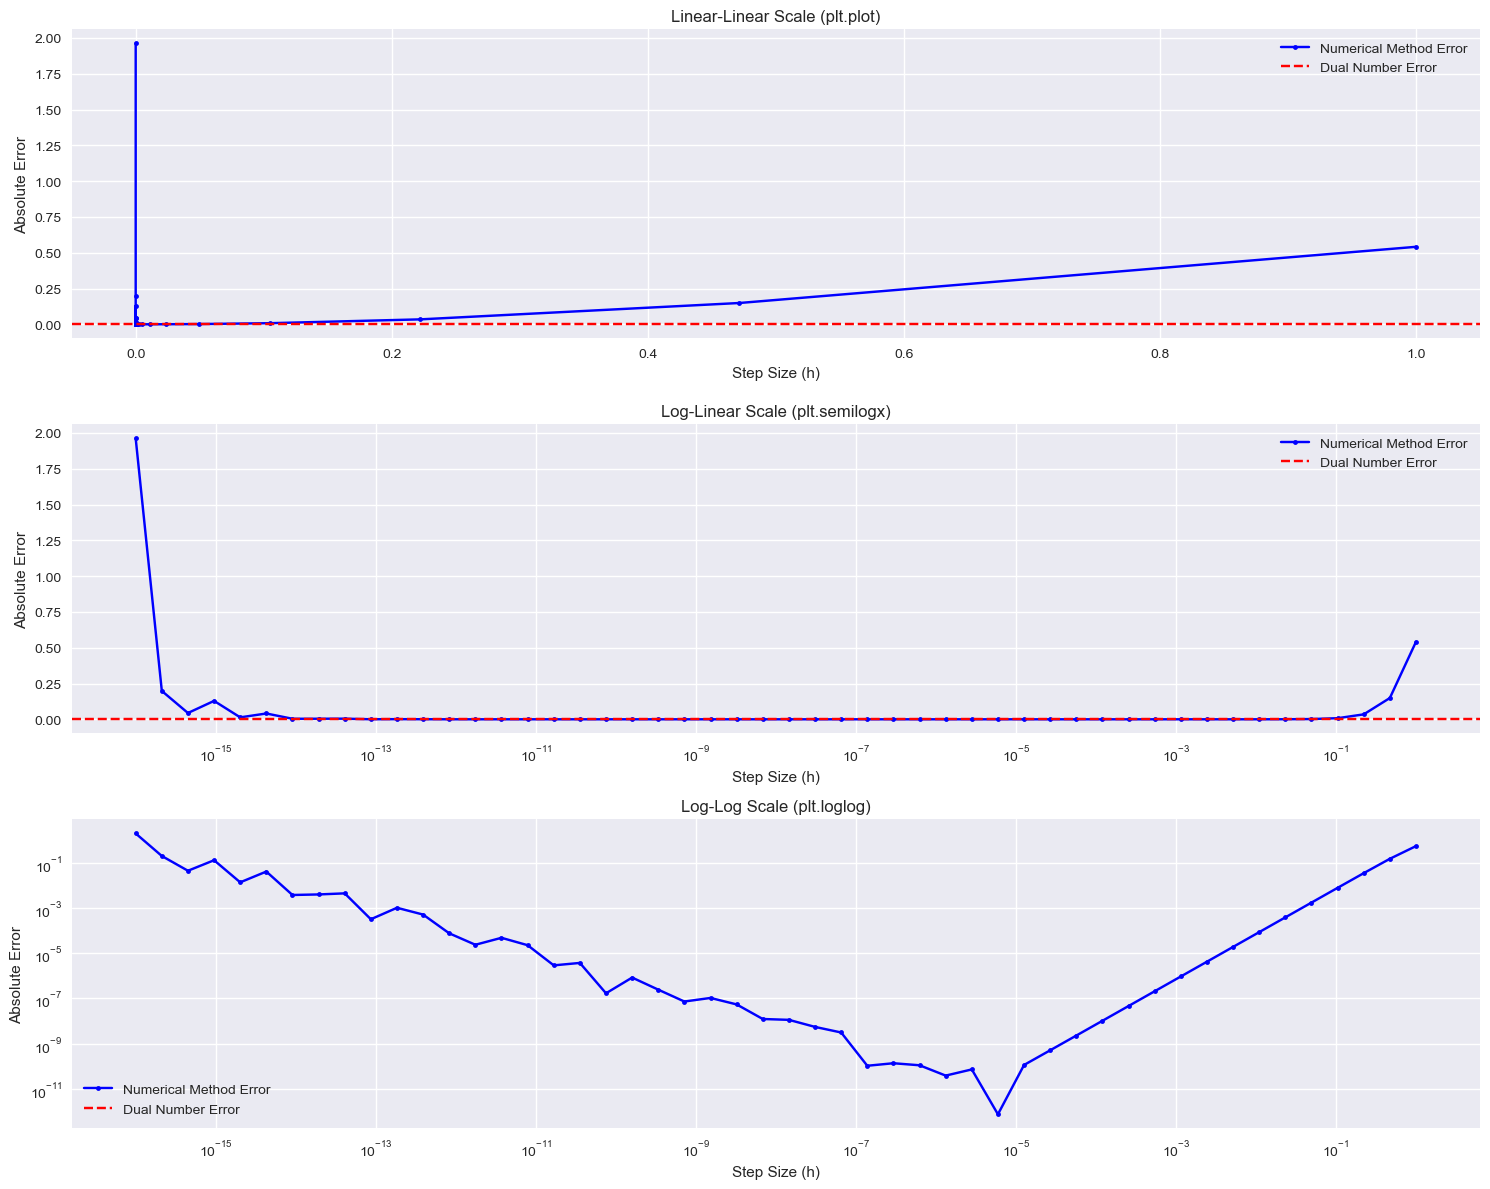

In [110]:
plt.style.use('seaborn')
fig, (ax1,ax2,ax3) = plt.subplots(3, 1, figsize=(15, 12))

ax1.plot(step_sizes_small, errors, 'b.-', label='Numerical Method Error')
ax1.axhline(y=dual_error, color='r', linestyle='--', label='Dual Number Error')
ax1.set_title('Linear-Linear Scale (plt.plot)')
ax1.set_xlabel('Step Size (h)')
ax1.set_ylabel('Absolute Error')
ax1.legend()
ax1.grid(True)

ax2.semilogx(step_sizes_small, errors, 'b.-', label='Numerical Method Error')
ax2.axhline(y=dual_error, color='r', linestyle='--', label='Dual Number Error')
ax2.set_title('Log-Linear Scale (plt.semilogx)')
ax2.set_xlabel('Step Size (h)')
ax2.set_ylabel('Absolute Error')
ax2.legend()
ax2.grid(True)

ax3.loglog(step_sizes_small, errors, 'b.-', label='Numerical Method Error')
ax3.axhline(y=dual_error, color='r', linestyle='--', label='Dual Number Error')
ax3.set_title('Log-Log Scale (plt.loglog)')
ax3.set_xlabel('Step Size (h)')
ax3.set_ylabel('Absolute Error')
ax3.legend()
ax3.grid(True)

plt.tight_layout()
plt.show()

In [111]:
# Print results
print(f"Derivative using dual numbers: {derivative_dual}")
print(f"Analytical derivative: {derivative_analytical}")
print(f"Relative error of dual method: {abs(derivative_dual - derivative_analytical)/abs(derivative_analytical)}")

Derivative using dual numbers: -1.9612372705533612
Analytical derivative: -1.9612372705533612
Relative error of dual method: 0.0
